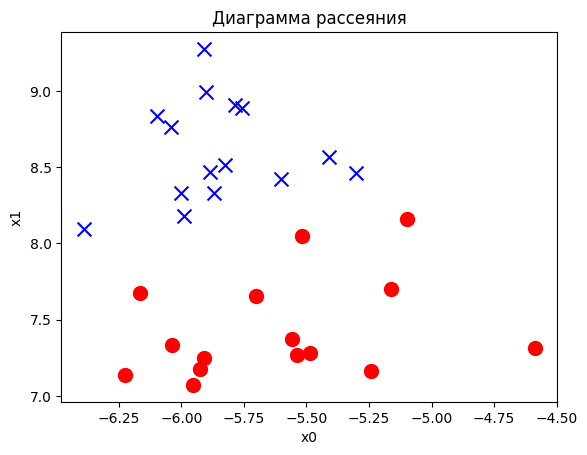

[[-2.49920793  6.14683189]]
[-64.2533988]


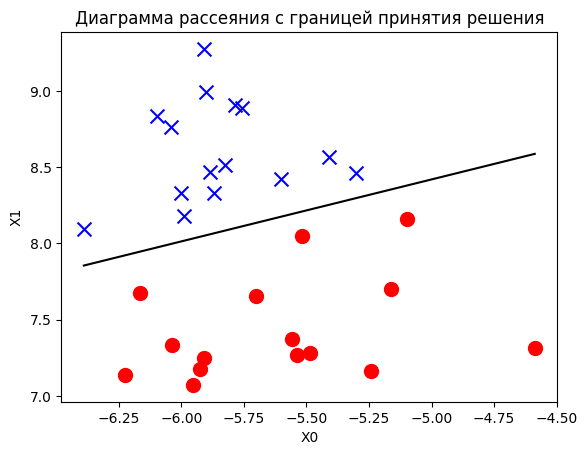

[[-5.51629264  8.04763857]
 [-5.30025769  8.46071981]
 [-5.9879581   8.18112559]]
[ 0  8 29]
[1 2]


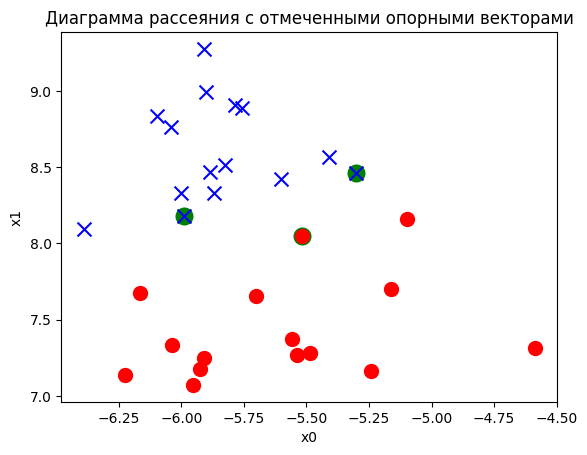

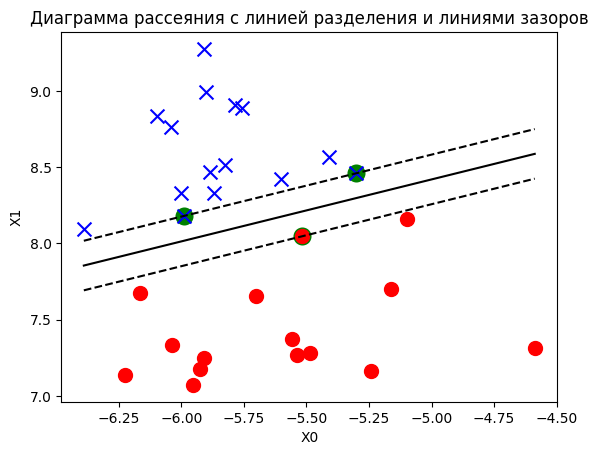

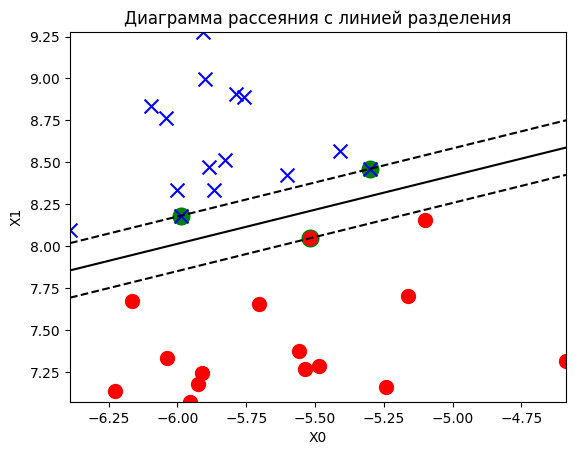

1.0
[[15  0]
 [ 0 15]]


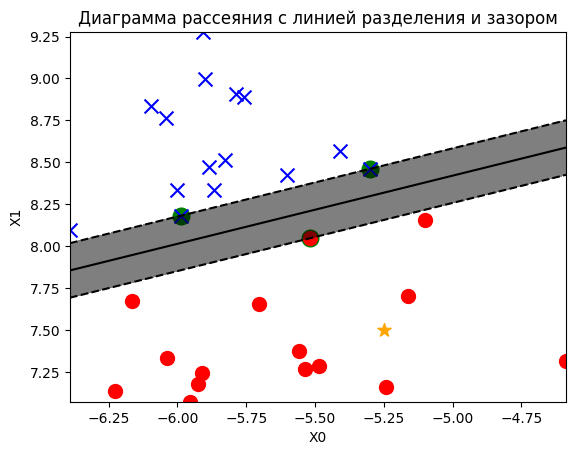

[-5.03131797]
[0]


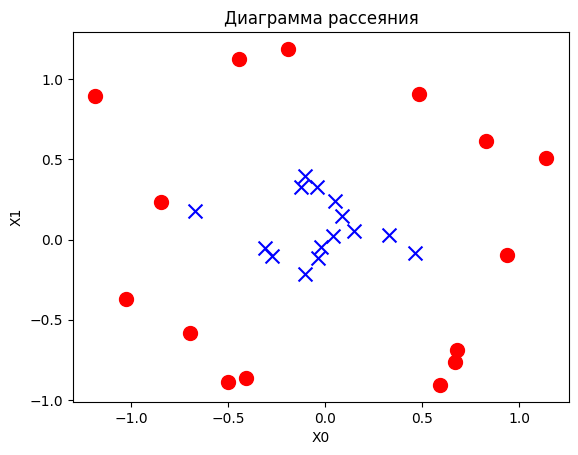

[6 2]
[11 20 21 23 28 29 25 27]
[[ 0.9388294  -0.09554628]
 [-0.84682371  0.23287306]
 [-0.19166925  1.18895776]
 [-0.69539045 -0.58523359]
 [ 0.68060508 -0.68615145]
 [ 0.48354792  0.91063288]
 [-0.66975235  0.17866445]
 [ 0.46427295 -0.08540628]]


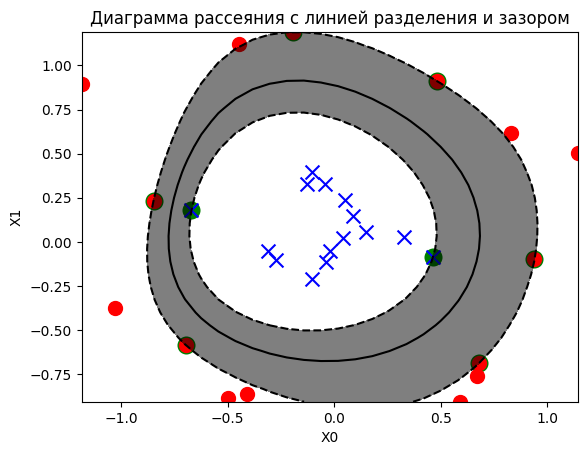

1.0
[[15  0]
 [ 0 15]]


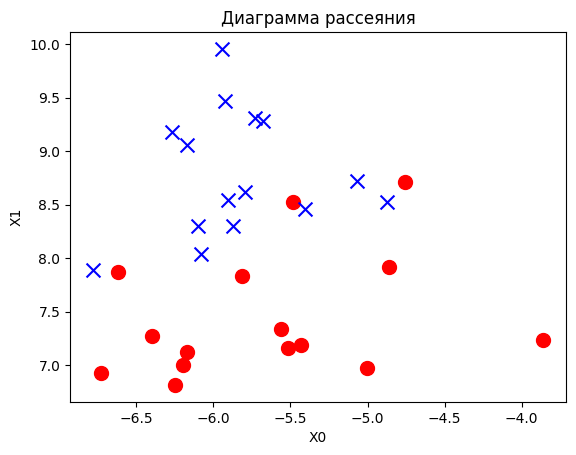

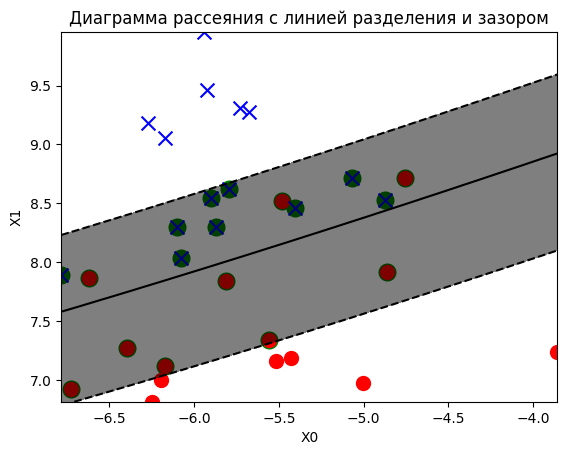

[9 9]
0.9
[[12  3]
 [ 0 15]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles
from sklearn.svm import SVC
from sklearn import metrics

# Задание 1: Линейно разделимый датасет
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

print(svm_linear.coef_)
print(svm_linear.intercept_)

X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
plt.plot(X0, -svm_linear.intercept_[0]/svm_linear.coef_[0][1] - svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.title("Диаграмма рассеяния c границей принятия решения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

print(svm_linear.support_vectors_)
print(svm_linear.support_)
print(svm_linear.n_support_)

plt.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.title("Диаграмма рассеяния c отмеченными опорными векторами")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

plt.plot(X0, -svm_linear.intercept_[0]/svm_linear.coef_[0][1] - svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')
plt.plot(X0, (-svm_linear.intercept_[0]-1)/svm_linear.coef_[0][1] - svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, linestyle='--', c='k')
plt.plot(X0, (-svm_linear.intercept_[0]+1)/svm_linear.coef_[0][1] - svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, linestyle='--', c='k')
plt.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.title("Диаграмма рассеяния c линией разделения и линиями зазоров")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)
Z = svm_linear.intercept_[0] + svm_linear.coef_[0][0] * X0_grid + svm_linear.coef_[0][1] * X1_grid
plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
plt.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.title("Диаграмма рассеяния c линией разделения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], linewidth=7, facecolors='green')
    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
    X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])
    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)
    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

y_pred = svm_linear.predict(X)
print(metrics.accuracy_score(y, y_pred))
print(metrics.confusion_matrix(y, y_pred))

observation_new = [[-5.25, 7.5]]
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

print(svm_linear.decision_function(observation_new))
print(svm_linear.predict(observation_new))

# Задание 2: Линейно неразделимые данные с зазором
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

svm_rbf = SVC(kernel='rbf', C=100).fit(X, y)

print(svm_rbf.n_support_)
print(svm_rbf.support_)
print(svm_rbf.support_vectors_)

plot_decision_regions(X, y, svm_rbf)

y_pred = svm_rbf.predict(X)
print(metrics.accuracy_score(y, y_pred))
print(metrics.confusion_matrix(y, y_pred))

# Задание 3: Данные без зазора
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

svm_poly = SVC(kernel='poly', degree=4, C=2).fit(X, y)

plot_decision_regions(X, y, svm_poly)

print(svm_poly.n_support_)

y_pred = svm_poly.predict(X)
print(metrics.accuracy_score(y, y_pred))
print(metrics.confusion_matrix(y, y_pred))